# FDA Adverse Event Reporting System (FAERS) Analysis
**Author:** Afriyie Karikari Bempah, PharmD  
**Data:** FDA FAERS API (live data)  
**Tools:** Python, requests, pandas, matplotlib

---

### Research Questions
1. Which drugs have the most adverse event reports?
2. Which drugs have the highest serious adverse event rates?
3. Who is being harmed — what are the patient demographics?
4. What reactions are patients actually experiencing?

---

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Connect to FDA FAERS API

In [2]:
# FDA OpenAPI base URL — no API key required
url = "https://api.fda.gov/drug/event.json"

# Test connection
response = requests.get(url, params={"count": "patient.drug.medicinalproduct.exact", "limit": 1})
print(f"API Status: {response.status_code} ({'Success' if response.status_code == 200 else 'Failed'})") 

API Status: 200 (Success)


## 2. Top 20 Drugs by Adverse Event Reports

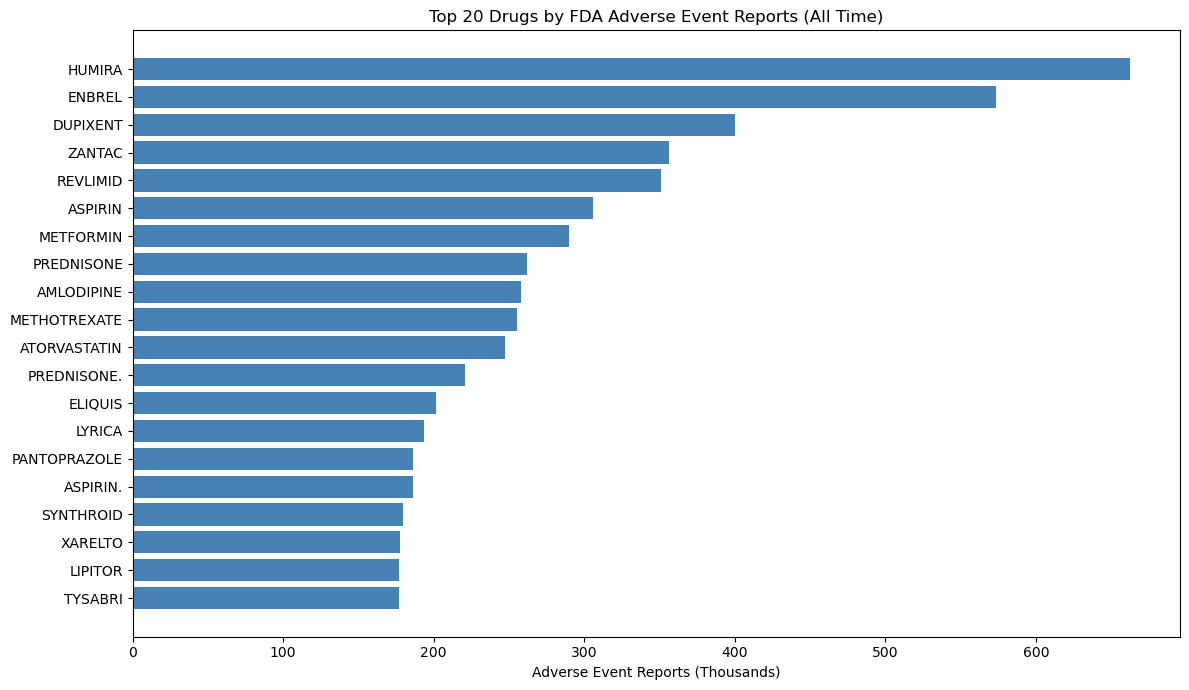

In [3]:
params = {
    "count": "patient.drug.medicinalproduct.exact",
    "limit": 20
}

response = requests.get(url, params=params)
data = response.json()

df_drugs = pd.DataFrame(data['results'])
df_drugs.columns = ['Drug_Name', 'Adverse_Event_Count']

plt.figure(figsize=(12, 7))
plt.barh(df_drugs['Drug_Name'], df_drugs['Adverse_Event_Count'] / 1000, color='steelblue')
plt.xlabel('Adverse Event Reports (Thousands)')
plt.title('Top 20 Drugs by FDA Adverse Event Reports (All Time)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart1_top20_drugs.png', dpi=150, bbox_inches='tight')
plt.show()

# Data quality note: Duplicate entries exist (e.g. 'ASPIRIN' and 'ASPIRIN.')
# reflecting inconsistent data entry in voluntary adverse event reporting.
# This is a known limitation of the FDA FAERS database.

## 3. Serious Adverse Event Rate by Drug

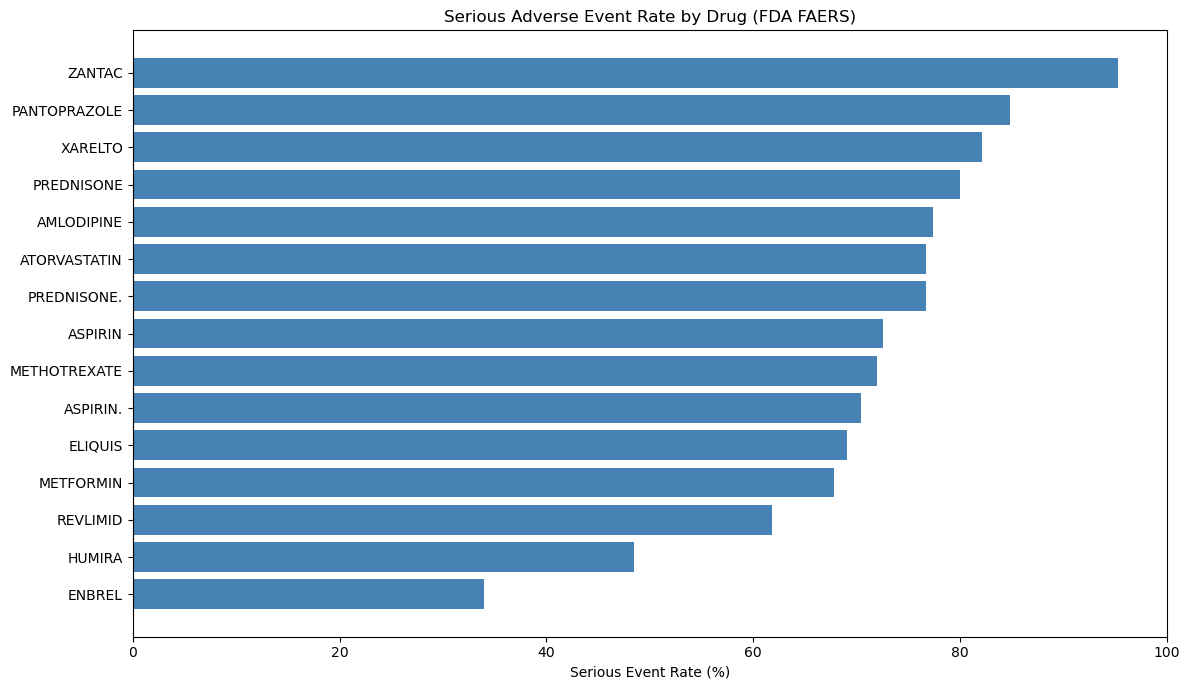

In [4]:
params_serious = {
    "search": "serious:1",
    "count": "patient.drug.medicinalproduct.exact",
    "limit": 20
}

response_serious = requests.get(url, params=params_serious)
data_serious = response_serious.json()
df_serious = pd.DataFrame(data_serious['results'])
df_serious.columns = ['Drug_Name', 'Serious_Count']

# merge and calculate serious rate
df_merged = pd.merge(df_drugs, df_serious, on='Drug_Name', how='inner')
df_merged['Serious_Rate'] = df_merged['Serious_Count'] / df_merged['Adverse_Event_Count']
df_merged = df_merged.sort_values('Serious_Rate', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(df_merged['Drug_Name'], df_merged['Serious_Rate'] * 100, color='steelblue')
plt.xlabel('Serious Event Rate (%)')
plt.title('Serious Adverse Event Rate by Drug (FDA FAERS)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_serious_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Zantac has the highest serious adverse event rate at ~95%,
# consistent with its 2020 market withdrawal due to NDMA carcinogen contamination.
# High report volume alone is misleading — Humira leads total reports but has
# a 49% serious rate vs Zantac's 95%. Safety surveillance requires
# both volume AND severity analysis.

## 4. Patient Demographics

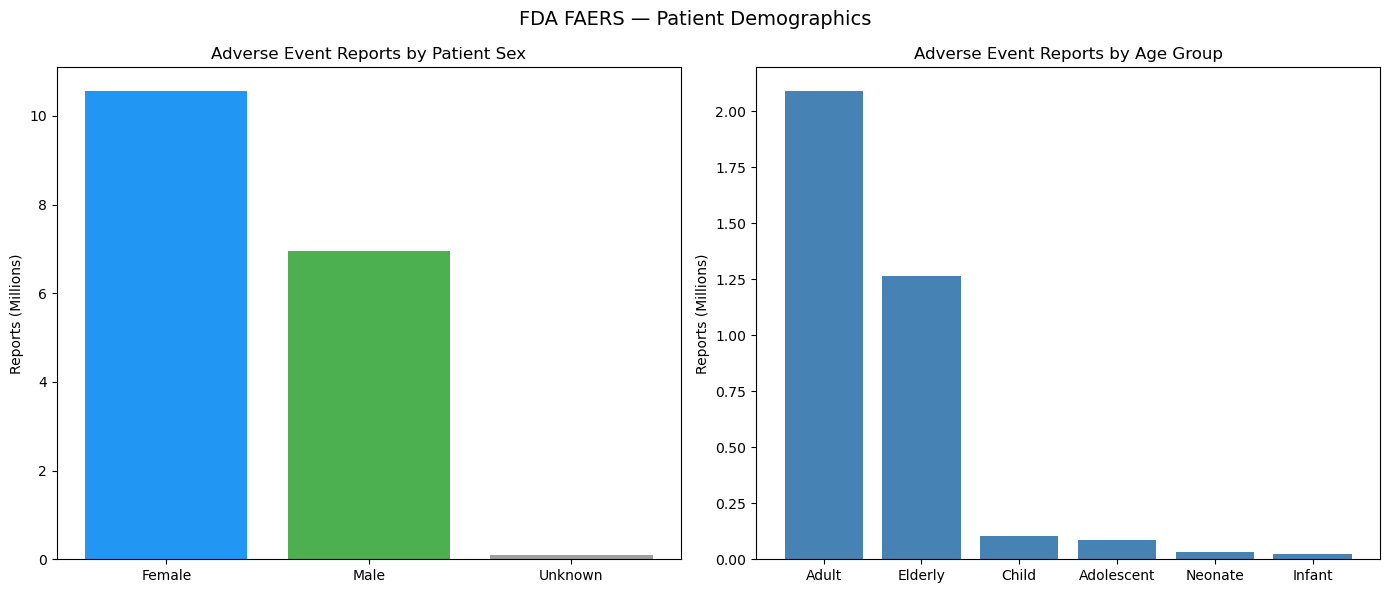

In [5]:
# sex breakdown
params_sex = {"count": "patient.patientsex", "limit": 10}
response_sex = requests.get(url, params=params_sex)
df_sex = pd.DataFrame(response_sex.json()['results'])
df_sex.columns = ['Sex', 'Count']
sex_map = {0: 'Unknown', 1: 'Male', 2: 'Female'}
df_sex['Sex'] = df_sex['Sex'].map(sex_map)

# age group breakdown
params_age = {"count": "patient.patientagegroup", "limit": 10}
response_age = requests.get(url, params=params_age)
df_age = pd.DataFrame(response_age.json()['results'])
df_age.columns = ['Age_Group', 'Count']
age_map = {1: 'Neonate', 2: 'Infant', 3: 'Child',
           4: 'Adolescent', 5: 'Adult', 6: 'Elderly'}
df_age['Age_Group'] = df_age['Age_Group'].map(age_map)

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(df_sex['Sex'], df_sex['Count'] / 1e6,
            color=['#2196F3', '#4CAF50', '#9E9E9E'])
axes[0].set_title('Adverse Event Reports by Patient Sex')
axes[0].set_ylabel('Reports (Millions)')

axes[1].bar(df_age['Age_Group'], df_age['Count'] / 1e6, color='steelblue')
axes[1].set_title('Adverse Event Reports by Age Group')
axes[1].set_ylabel('Reports (Millions)')

plt.suptitle('FDA FAERS — Patient Demographics', fontsize=14)
plt.tight_layout()
plt.savefig('chart3_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Female patients account for ~60% of all adverse event reports,
# reflecting both higher reporting rates and disproportionate prescribing
# of high-risk drug classes. Adults and elderly represent 95%+ of reports,
# consistent with chronic disease medication use concentrated in older populations.

## 5. Top 20 Adverse Reactions

In [ ]:
params_reaction = {
    "count": "patient.reaction.reactionmeddrapt.exact",
    "limit": 20
}

response_reaction = requests.get(url, params=params_reaction)
df_reaction = pd.DataFrame(response_reaction.json()['results'])
df_reaction.columns = ['Reaction', 'Count']

plt.figure(figsize=(12, 7))
plt.barh(df_reaction['Reaction'], df_reaction['Count'] / 1e6, color='steelblue')
plt.xlabel('Reports (Millions)')
plt.title('Top 20 Adverse Reactions — FDA FAERS (All Time)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart4_reactions.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: "Drug Ineffective" is the single most reported adverse reaction,
# surpassing even death (824K reports). This highlights a critical gap between
# clinical trial efficacy and real-world effectiveness — a core challenge
# in pharmacovigilance and post-market drug surveillance.

## 6. Conclusions

| Finding | Implication |
|---|---|
| Zantac has 95% serious event rate | Carcinogen contamination signal visible in reporting data — confirmed by 2020 withdrawal |
| Drug Ineffective is #1 reaction | Real-world effectiveness consistently falls short of clinical trial results |
| Women report 60% of adverse events | Sex-based differences in drug response are underrecognized in clinical practice |
| Adults + elderly = 95%+ of reports | Pediatric adverse event surveillance remains a gap in pharmacovigilance |
| High volume ≠ high risk | Safety monitoring requires both volume and severity analysis |

---

**Data Source:** FDA Adverse Event Reporting System (FAERS) via OpenFDA API  
**Analysis by:** Afriyie Karikari Bempah, PharmD | [LinkedIn](https://linkedin.com/in/afriyiekarikaribempah) | [GitHub](https://github.com/akbempah1)